# 🤖 Model Training & Evaluation for Fraud Detection

## 📌 Purpose

This notebook trains, tunes, and evaluates **machine learning models** using engineered features from Feature Engineering notebook.

---

## 🎯 Modeling Strategy

### Models to Train

1. **🎯 Logistic Regression**: Baseline with interpretable coefficients
2. **🚀 XGBoost**: Gradient boosting (industry standard)
3. **⚡ LightGBM**: Fast gradient boosting
4. **🌲 Random Forest**: Ensemble of decision trees

### Handling Class Imbalance (0.13% fraud)

We'll compare **THREE strategies**:

| Strategy | Approach | Models |
|----------|----------|--------|
| **1. Class Weights** | Penalize misclassified minorities | All models |
| **2. SMOTE** | Synthetic oversampling | Tree models |
| **3. Threshold Tuning** | Adjust decision boundary | All models |

### Key Features

✅ **Hyperparameter Tuning**: RandomizedSearchCV (PR-AUC optimization)  
✅ **Two Pipelines**: `full` (tree models) vs `linear` (logistic)  
✅ **Early Stopping**: Prevent overfitting  
✅ **Feature Importance**: SHAP + built-in importance  
✅ **Threshold Optimization**: Business-driven cutoff selection  
✅ **Cost-Benefit Analysis**: Real-world impact estimation  

### Evaluation Metrics

**Primary**:
- **PR-AUC**: Best for imbalanced data
- **Precision @ 90% Recall**: Business requirement (catch 90% fraud)

**Secondary**:
- ROC-AUC, F1-Score, Confusion Matrix

---

## 1. Setup & Imports

### Library Overview

- **Models**: sklearn, xgboost, lightgbm
- **Imbalance**: imblearn (SMOTE)
- **Tuning**: RandomizedSearchCV
- **Interpretation**: shap (optional, install if needed)
- **Visualization**: matplotlib, seaborn

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# SMOTE for class imbalance
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import BorderlineSMOTE


# Evaluation metrics
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    make_scorer,
    accuracy_score
)

# Utilities
import joblib
import pickle
import os
import json
import warnings
from datetime import datetime
import time
from collections import defaultdict

# SHAP for model interpretation (optional)
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('⚠️  SHAP not installed. Install with: pip install shap')

# Configuration
warnings.filterwarnings('ignore')
np.random.seed(42)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
pd.set_option('display.max_columns', None)

# Plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14, 6)

print('✅ Libraries imported successfully!')
print(f'📅 Training started: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'🧠 SHAP available: {SHAP_AVAILABLE}')

✅ Libraries imported successfully!
📅 Training started: 2026-01-02 17:01:34
🧠 SHAP available: True


---
## 2. Load Artifacts & Data

### What We Load

1. **Preprocessors**: `full` (24 features) and `linear` (22 features)
2. **Train/Val/Test CSVs**: Already transformed and split (70/15/15)
3. **Feature Config**: Metadata about features

### Data Verification

- Check fraud rates are consistent (~0.13%)
- Verify no data leakage
- Confirm feature counts

In [2]:
artifacts_path = '../artifacts'

print('='*80)
print('📂 LOADING ARTIFACTS')
print('='*80)

# Verify artifacts folder exists
if not os.path.exists(artifacts_path):
    raise FileNotFoundError(
        f"Artifacts folder not found at '{artifacts_path}'. "
        "Please run Feature_Engineering.ipynb first."
    )

# Load preprocessors
preprocessor_full = joblib.load(f'{artifacts_path}/preprocessor_full.pkl')
preprocessor_linear = joblib.load(f'{artifacts_path}/preprocessor_linear.pkl')
print('✅ Preprocessors loaded')

# Load feature config
with open(f'{artifacts_path}/feature_config.pkl', 'rb') as f:
    feature_config = pickle.load(f)
print('✅ Feature config loaded')

# Load datasets
train_df = pd.read_csv(f'{artifacts_path}/data/train.csv')
val_df = pd.read_csv(f'{artifacts_path}/data/val.csv')
test_df = pd.read_csv(f'{artifacts_path}/data/test.csv')

print(f'\n📊 Dataset Sizes:')
print(f'  • Training:   {len(train_df):,} samples ({train_df["isFraud"].mean()*100:.4f}% fraud)')
print(f'  • Validation: {len(val_df):,} samples ({val_df["isFraud"].mean()*100:.4f}% fraud)')
print(f'  • Test:       {len(test_df):,} samples ({test_df["isFraud"].mean()*100:.4f}% fraud)')

# Separate features and target
X_train = train_df.drop('isFraud', axis=1)
y_train = train_df['isFraud']

X_val = val_df.drop('isFraud', axis=1)
y_val = val_df['isFraud']

X_test = test_df.drop('isFraud', axis=1)
y_test = test_df['isFraud']

print(f'\n📊 Feature Details:')
print(f'  • Full pipeline features: {len(feature_config["feature_names_full"])}')
print(f'  • Linear pipeline features: {len(feature_config["feature_names_linear"])}')
print(f'  • Data already transformed: Yes')

# Calculate class imbalance metrics
fraud_count = (y_train == 1).sum()
non_fraud_count = (y_train == 0).sum()
imbalance_ratio = non_fraud_count / fraud_count

print(f'\n⚖️  Class Imbalance:')
print(f'  • Non-Fraud: {non_fraud_count:,} ({non_fraud_count/len(y_train)*100:.2f}%)')
print(f'  • Fraud:     {fraud_count:,} ({fraud_count/len(y_train)*100:.2f}%)')
print(f'  • Ratio:     {imbalance_ratio:.0f}:1')

print('\n' + '='*80)

📂 LOADING ARTIFACTS
✅ Preprocessors loaded
✅ Feature config loaded

📊 Dataset Sizes:
  • Training:   4,453,834 samples (0.1291% fraud)
  • Validation: 954,393 samples (0.1291% fraud)
  • Test:       954,393 samples (0.1291% fraud)

📊 Feature Details:
  • Full pipeline features: 24
  • Linear pipeline features: 22
  • Data already transformed: Yes

⚖️  Class Imbalance:
  • Non-Fraud: 4,448,085 (99.87%)
  • Fraud:     5,749 (0.13%)
  • Ratio:     774:1



---
## 3. Helper Functions

### Modular Evaluation Framework

We create reusable functions for:
1. **Comprehensive evaluation** with all fraud metrics
2. **Threshold optimization** for business requirements
3. **Visualization suite** (confusion matrix, ROC, PR curves)
4. **Feature importance** analysis
5. **Cost-benefit analysis** (business impact)

In [3]:
def evaluate_model(model, X, y, dataset_name='Validation', optimal_threshold=None):
    """
    Comprehensive model evaluation with fraud detection metrics.
    
    Args:
        model: Trained classifier
        X: Features
        y: True labels
        dataset_name: Name for display
        optimal_threshold: Pre-computed threshold (if None, will optimize)
    
    Returns:
        dict: All evaluation metrics and predictions
    """
    # Get probability predictions
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    # Find optimal threshold using F1-score (if not provided)
    if optimal_threshold is None:
        precisions, recalls, thresholds = precision_recall_curve(y, y_pred_proba)
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
        optimal_idx = np.argmax(f1_scores)
        optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
    
    # Apply threshold
    y_pred = (y_pred_proba >= optimal_threshold).astype(int)
    
    # Calculate metrics
    roc_auc = roc_auc_score(y, y_pred_proba)
    pr_auc = average_precision_score(y, y_pred_proba)
    precision = precision_score(y, y_pred, zero_division=0)
    recall = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    accuracy = accuracy_score(y, y_pred)
    
    # Precision @ 90% Recall (business requirement)
    precisions_curve, recalls_curve, _ = precision_recall_curve(y, y_pred_proba)
    idx_90_recall = np.argmin(np.abs(recalls_curve - 0.90))
    precision_at_90_recall = precisions_curve[idx_90_recall]
    
    # Confusion matrix components
    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Print results
    print(f'\n{"="*70}')
    print(f'📊 {dataset_name} Set Evaluation')
    print(f'{"="*70}')
    print(f'ROC-AUC:                  {roc_auc:.4f}')
    print(f'PR-AUC (Primary Metric):  {pr_auc:.4f}')
    print(f'Optimal Threshold:        {optimal_threshold:.4f}')
    print(f'Accuracy:                 {accuracy:.4f}')
    print(f'Precision:                {precision:.4f}')
    print(f'Recall:                   {recall:.4f}')
    print(f'F1-Score:                 {f1:.4f}')
    print(f'Precision @ 90% Recall:   {precision_at_90_recall:.4f}')
    print(f'\nConfusion Matrix:')
    print(f'  TN: {tn:,} | FP: {fp:,}')
    print(f'  FN: {fn:,} | TP: {tp:,}')
    print(f'{"="*70}')
    
    return {
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'optimal_threshold': optimal_threshold,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'precision_at_90_recall': precision_at_90_recall,
        'y_pred_proba': y_pred_proba,
        'y_pred': y_pred,
        'confusion_matrix': cm,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }


def plot_confusion_matrix(y_true, y_pred, model_name, normalize=False):
    """
    Plot confusion matrix with percentages.
    """
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        annot = np.array([[f'{val:,}\n({norm:.1%})' 
                          for val, norm in zip(row, norm_row)] 
                         for row, norm_row in zip(cm, cm_normalized)])
        fmt = ''
    else:
        annot = cm
        fmt = ',d'
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=annot, fmt=fmt, cmap='Blues', 
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'],
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix - {model_name}', fontsize=14, weight='bold', pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Print breakdown
    tn, fp, fn, tp = cm.ravel()
    print(f'\n📊 Confusion Matrix Breakdown:')
    print(f'  • True Negatives:  {tn:,} (correctly identified legitimate)')
    print(f'  • False Positives: {fp:,} (legitimate flagged as fraud)')
    print(f'  • False Negatives: {fn:,} (fraud missed)')
    print(f'  • True Positives:  {tp:,} (correctly caught fraud)')
    print(f'\n💡 False Positive Rate: {fp/(fp+tn)*100:.2f}%')
    print(f'💡 False Negative Rate: {fn/(fn+tp)*100:.2f}%')


def plot_roc_pr_curves(y_true, y_pred_proba, model_name):
    """
    Plot ROC and Precision-Recall curves side by side.
    """
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    # PR Curve
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = average_precision_score(y_true, y_pred_proba)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # ROC Curve
    axes[0].plot(fpr, tpr, color='#2E86AB', lw=3, 
                 label=f'Model (AUC = {roc_auc:.4f})')
    axes[0].plot([0, 1], [0, 1], color='#A23B72', lw=2, linestyle='--', 
                 label='Random Baseline')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate', fontsize=12, weight='bold')
    axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12, weight='bold')
    axes[0].set_title(f'ROC Curve - {model_name}', fontsize=14, weight='bold', pad=15)
    axes[0].legend(loc="lower right", fontsize=11)
    axes[0].grid(alpha=0.3, linestyle=':')
    
    # PR Curve
    axes[1].plot(recall, precision, color='#2E86AB', lw=3,
                 label=f'Model (AUC = {pr_auc:.4f})')
    axes[1].axhline(y=y_true.mean(), color='#A23B72', linestyle='--', lw=2, 
                    label=f'Baseline ({y_true.mean()*100:.3f}% fraud)')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall', fontsize=12, weight='bold')
    axes[1].set_ylabel('Precision', fontsize=12, weight='bold')
    axes[1].set_title(f'Precision-Recall Curve - {model_name}', 
                     fontsize=14, weight='bold', pad=15)
    axes[1].legend(loc="upper right", fontsize=11)
    axes[1].grid(alpha=0.3, linestyle=':')
    
    plt.tight_layout()
    plt.show()


def plot_threshold_analysis(y_true, y_pred_proba, model_name):
    """
    Analyze how metrics change with different thresholds.
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_pred_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    # Ensure arrays are same length
    min_len = min(len(thresholds), len(precisions)-1, len(recalls)-1, len(f1_scores)-1)
    thresholds = thresholds[:min_len]
    precisions = precisions[:min_len]
    recalls = recalls[:min_len]
    f1_scores = f1_scores[:min_len]
    
    plt.figure(figsize=(12, 6))
    plt.plot(thresholds, precisions, label='Precision', linewidth=2.5, color='#06D6A0')
    plt.plot(thresholds, recalls, label='Recall', linewidth=2.5, color='#EF476F')
    plt.plot(thresholds, f1_scores, label='F1-Score', linewidth=2.5, color='#118AB2')
    
    # Mark optimal F1 threshold
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    plt.axvline(x=optimal_threshold, color='black', linestyle='--', linewidth=2,
                label=f'Optimal (F1) = {optimal_threshold:.3f}')
    
    plt.xlabel('Threshold', fontsize=12, weight='bold')
    plt.ylabel('Score', fontsize=12, weight='bold')
    plt.title(f'Threshold Analysis - {model_name}', fontsize=14, weight='bold', pad=15)
    plt.legend(loc='best', fontsize=11)
    plt.grid(alpha=0.3, linestyle=':')
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.tight_layout()
    plt.show()
    
    print(f'\n🎯 Optimal Threshold (by F1): {optimal_threshold:.4f}')
    print(f'   • Precision: {precisions[optimal_idx]:.4f}')
    print(f'   • Recall:    {recalls[optimal_idx]:.4f}')
    print(f'   • F1-Score:  {f1_scores[optimal_idx]:.4f}')


def calculate_business_impact(results, avg_fraud_amount=5000, investigation_cost=50):
    """
    Calculate business impact of model predictions.
    
    Args:
        results: Dict from evaluate_model()
        avg_fraud_amount: Average $ value of fraud
        investigation_cost: Cost to investigate a flagged transaction
    
    Returns:
        dict: Business metrics
    """
    tp, fp, fn, tn = results['tp'], results['fp'], results['fn'], results['tn']
    
    # Calculate costs
    fraud_prevented = tp * avg_fraud_amount
    fraud_lost = fn * avg_fraud_amount
    investigation_costs = (tp + fp) * investigation_cost
    
    net_savings = fraud_prevented - investigation_costs
    
    # Without model (all fraud goes through)
    total_fraud = (tp + fn) * avg_fraud_amount
    
    roi = (net_savings / total_fraud) * 100 if total_fraud > 0 else 0
    
    print(f'\n💰 BUSINESS IMPACT ANALYSIS')
    print(f'{"="*70}')
    print(f'Assumptions:')
    print(f'  • Average fraud amount: ${avg_fraud_amount:,}')
    print(f'  • Investigation cost:   ${investigation_cost:,}')
    print(f'\nResults:')
    print(f'  • Fraud prevented:      ${fraud_prevented:,.0f} ({tp:,} cases)')
    print(f'  • Fraud missed:         ${fraud_lost:,.0f} ({fn:,} cases)')
    print(f'  • Investigation costs:  ${investigation_costs:,.0f} ({tp+fp:,} investigations)')
    print(f'  • Net savings:          ${net_savings:,.0f}')
    print(f'  • ROI:                  {roi:.1f}%')
    print(f'{"="*70}')
    
    return {
        'fraud_prevented': fraud_prevented,
        'fraud_lost': fraud_lost,
        'investigation_costs': investigation_costs,
        'net_savings': net_savings,
        'roi': roi
    }


print('✅ Helper functions defined!')

✅ Helper functions defined!


---
## 4. Apply SMOTE (Optional Strategy)

### SMOTE vs Class Weights

We'll test **both approaches** and compare:

| Approach | Pros | Cons | Best For |
|----------|------|------|----------|
| **SMOTE** | Creates synthetic samples, better minority learning | Slower training, potential overfitting | Complex patterns |
| **Class Weights** | Fast, no data modification | May not capture minority nuances | Simple patterns |

### Strategy

- Balance to **20% fraud** (not 50% to avoid overfitting)
- Apply **only to training** data
- Keep validation/test untouched

In [4]:
print('='*80)
print('🔄 APPLYING SMOTE (OPTIONAL STRATEGY)')
print('='*80)

print(f'\n📊 Original Class Distribution:')
print(f'  • Non-Fraud: {non_fraud_count:,} ({non_fraud_count/len(y_train)*100:.2f}%)')
print(f'  • Fraud:     {fraud_count:,} ({fraud_count/len(y_train)*100:.2f}%)')
print(f'  • Ratio:     {imbalance_ratio:.0f}:1')

# Apply SMOTE to balance to ~20% fraud
print('\n⏳ Applying SMOTE (target: 20% fraud)...')
smote = SMOTE(sampling_strategy=0.25, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

fraud_count_smote = (y_train_smote == 1).sum()
non_fraud_count_smote = (y_train_smote == 0).sum()

print(f'\n✅ SMOTE Applied!')
print(f'\n📊 After SMOTE:')
print(f'  • Non-Fraud: {non_fraud_count_smote:,} ({non_fraud_count_smote/len(y_train_smote)*100:.2f}%)')
print(f'  • Fraud:     {fraud_count_smote:,} ({fraud_count_smote/len(y_train_smote)*100:.2f}%)')
print(f'  • New samples created: {len(y_train_smote) - len(y_train):,}')
print(f'  • Total training samples: {len(y_train_smote):,}')

print('\n' + '='*80)

🔄 APPLYING SMOTE (OPTIONAL STRATEGY)

📊 Original Class Distribution:
  • Non-Fraud: 4,448,085 (99.87%)
  • Fraud:     5,749 (0.13%)
  • Ratio:     774:1

⏳ Applying SMOTE (target: 20% fraud)...

✅ SMOTE Applied!

📊 After SMOTE:
  • Non-Fraud: 4,448,085 (80.00%)
  • Fraud:     1,112,021 (20.00%)
  • New samples created: 1,106,272
  • Total training samples: 5,560,106



---
## 5. Model 1: Logistic Regression (Baseline)

### Configuration

- **Purpose**: Establishes baseline performance
- **Features**: Linear feature set (22 features, no multicollinearity)
- **Class Imbalance**: `class_weight='balanced'`
- **Interpretability**: ✅ Highly interpretable coefficients

### Why Logistic Regression?

- Fast training and prediction
- Interpretable coefficients (feature impact)
- Benchmark for more complex models


🎯 MODEL 1: LOGISTIC REGRESSION (BASELINE)

⏳ Training Logistic Regression...
✅ Training completed in 209.27 seconds

📊 Validation Set Evaluation
ROC-AUC:                  0.9972
PR-AUC (Primary Metric):  0.6414
Optimal Threshold:        0.9998
Accuracy:                 0.9991
Precision:                0.6828
Recall:                   0.5032
F1-Score:                 0.5794
Precision @ 90% Recall:   0.1932

Confusion Matrix:
  TN: 952,873 | FP: 288
  FN: 612 | TP: 620


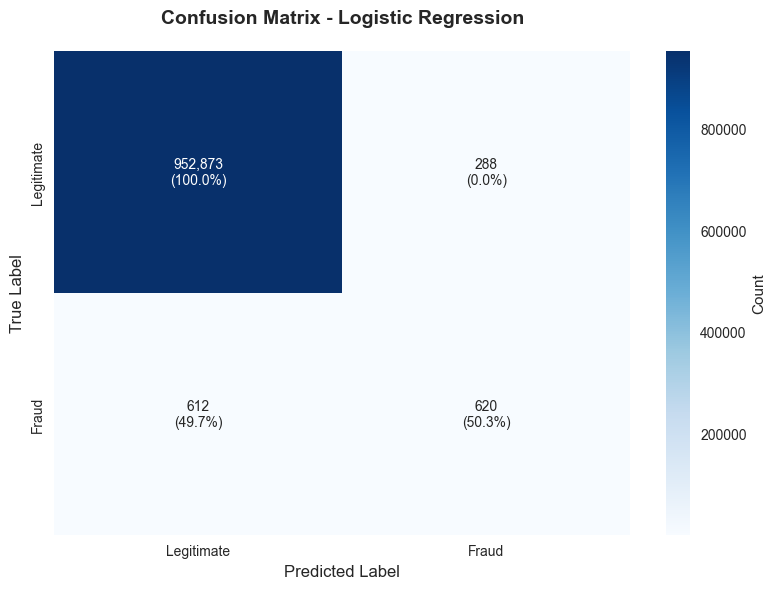


📊 Confusion Matrix Breakdown:
  • True Negatives:  952,873 (correctly identified legitimate)
  • False Positives: 288 (legitimate flagged as fraud)
  • False Negatives: 612 (fraud missed)
  • True Positives:  620 (correctly caught fraud)

💡 False Positive Rate: 0.03%
💡 False Negative Rate: 49.68%


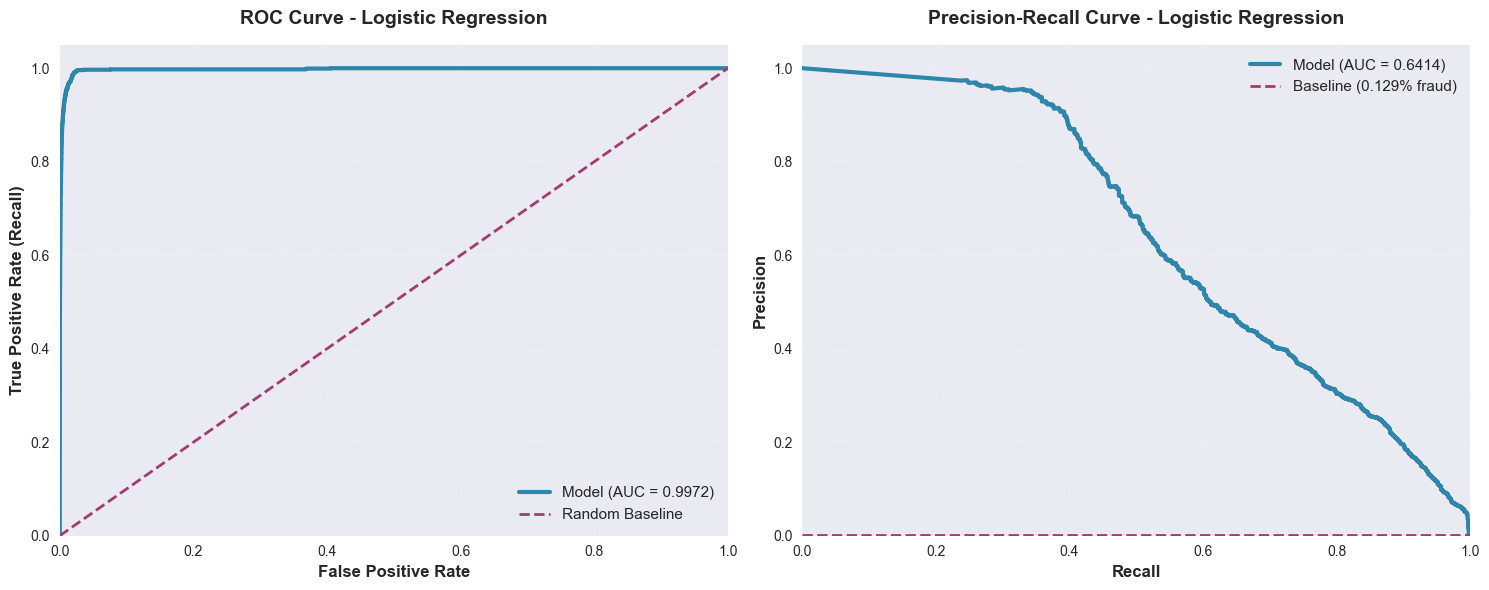

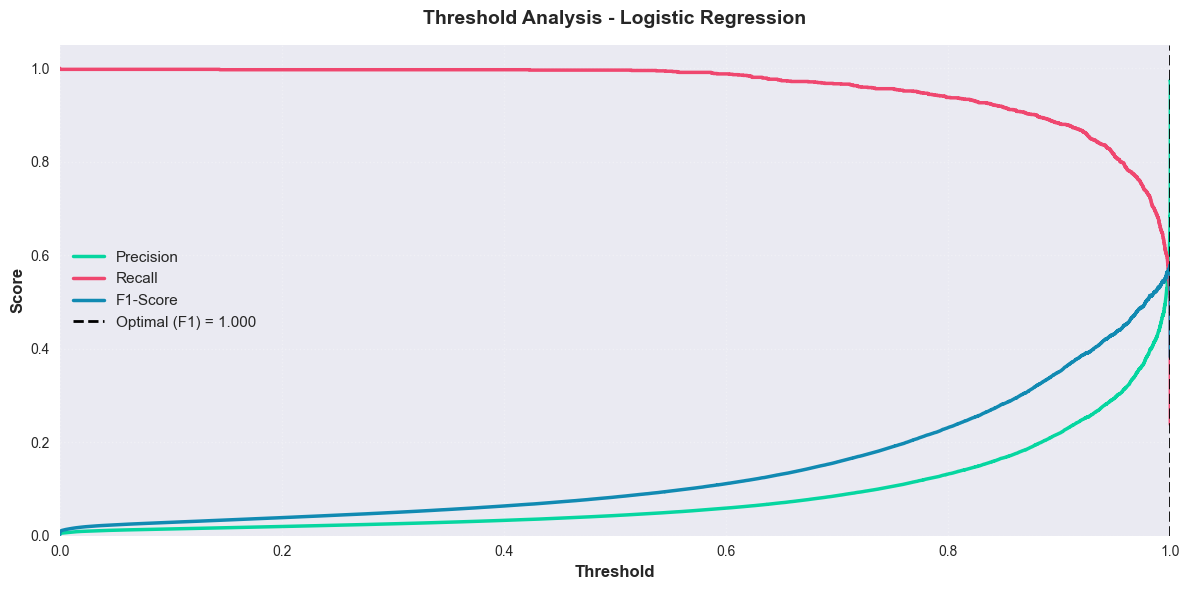


🎯 Optimal Threshold (by F1): 0.9998
   • Precision: 0.6828
   • Recall:    0.5032
   • F1-Score:  0.5794

💰 BUSINESS IMPACT ANALYSIS
Assumptions:
  • Average fraud amount: $5,000
  • Investigation cost:   $50

Results:
  • Fraud prevented:      $3,100,000 (620 cases)
  • Fraud missed:         $3,060,000 (612 cases)
  • Investigation costs:  $45,400 (908 investigations)
  • Net savings:          $3,054,600
  • ROI:                  49.6%

💾 Model saved: model_logistic_regression.pkl


In [5]:
print('\n' + '='*80)
print('🎯 MODEL 1: LOGISTIC REGRESSION (BASELINE)')
print('='*80)

print('\n⏳ Training Logistic Regression...')
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # Handle imbalance
    random_state=42,
    n_jobs=-1,
    solver='lbfgs',
    C=1.0,
    penalty='l2'
)

lr_model.fit(X_train, y_train)
training_time = time.time() - start_time

print(f'✅ Training completed in {training_time:.2f} seconds')

# Evaluate on validation set
lr_results = evaluate_model(lr_model, X_val, y_val, 'Validation')

# Visualizations
plot_confusion_matrix(y_val, lr_results['y_pred'], 'Logistic Regression', normalize=True)
plot_roc_pr_curves(y_val, lr_results['y_pred_proba'], 'Logistic Regression')
plot_threshold_analysis(y_val, lr_results['y_pred_proba'], 'Logistic Regression')

# Business impact
lr_business = calculate_business_impact(lr_results)

# Save model
joblib.dump(lr_model, f'{artifacts_path}/model_logistic_regression.pkl')
print(f'\n💾 Model saved: model_logistic_regression.pkl')

# Store results for comparison
model_results = {
    'Logistic Regression': {
        'model': lr_model,
        'results': lr_results,
        'business': lr_business,
        'training_time': training_time,
        'use_smote': False
    }
}

---
## 6. Model 2: XGBoost with Hyperparameter Tuning

### Configuration

- **Features**: Full feature set (24 features)
- **Data**: SMOTE-balanced training data
- **Tuning**: RandomizedSearchCV (20 iterations)
- **Metric**: PR-AUC (best for imbalanced data)
- **Early Stopping**: Prevents overfitting

### Hyperparameter Search Space

```python
{
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5]
}
```


🚀 MODEL 2: XGBOOST WITH HYPERPARAMETER TUNING

⏳ Starting hyperparameter tuning (10 iterations, 3-fold CV)...
   This may take 5-10 minutes...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
✅ Tuning completed in 8.22 minutes

📊 Validation Set Evaluation
ROC-AUC:                  0.9999
PR-AUC (Primary Metric):  0.9982
Optimal Threshold:        0.9952
Accuracy:                 1.0000
Precision:                1.0000
Recall:                   0.9968
F1-Score:                 0.9984
Precision @ 90% Recall:   1.0000

Confusion Matrix:
  TN: 953,161 | FP: 0
  FN: 4 | TP: 1,228

🏆 Best Parameters:
   • subsample: 0.9
   • n_estimators: 300
   • min_child_weight: 5
   • max_depth: 10
   • learning_rate: 0.1
   • gamma: 0.1
   • colsample_bytree: 0.7

📊 Best CV PR-AUC Score: 1.0000


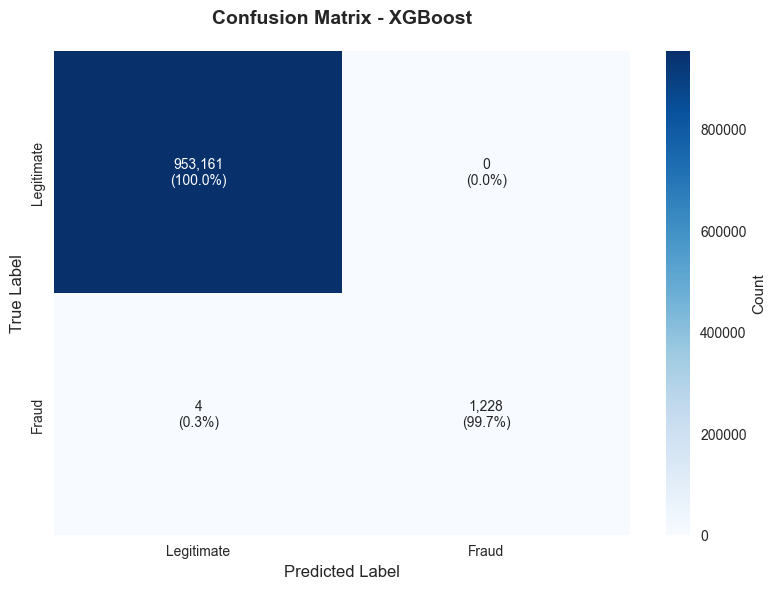


📊 Confusion Matrix Breakdown:
  • True Negatives:  953,161 (correctly identified legitimate)
  • False Positives: 0 (legitimate flagged as fraud)
  • False Negatives: 4 (fraud missed)
  • True Positives:  1,228 (correctly caught fraud)

💡 False Positive Rate: 0.00%
💡 False Negative Rate: 0.32%


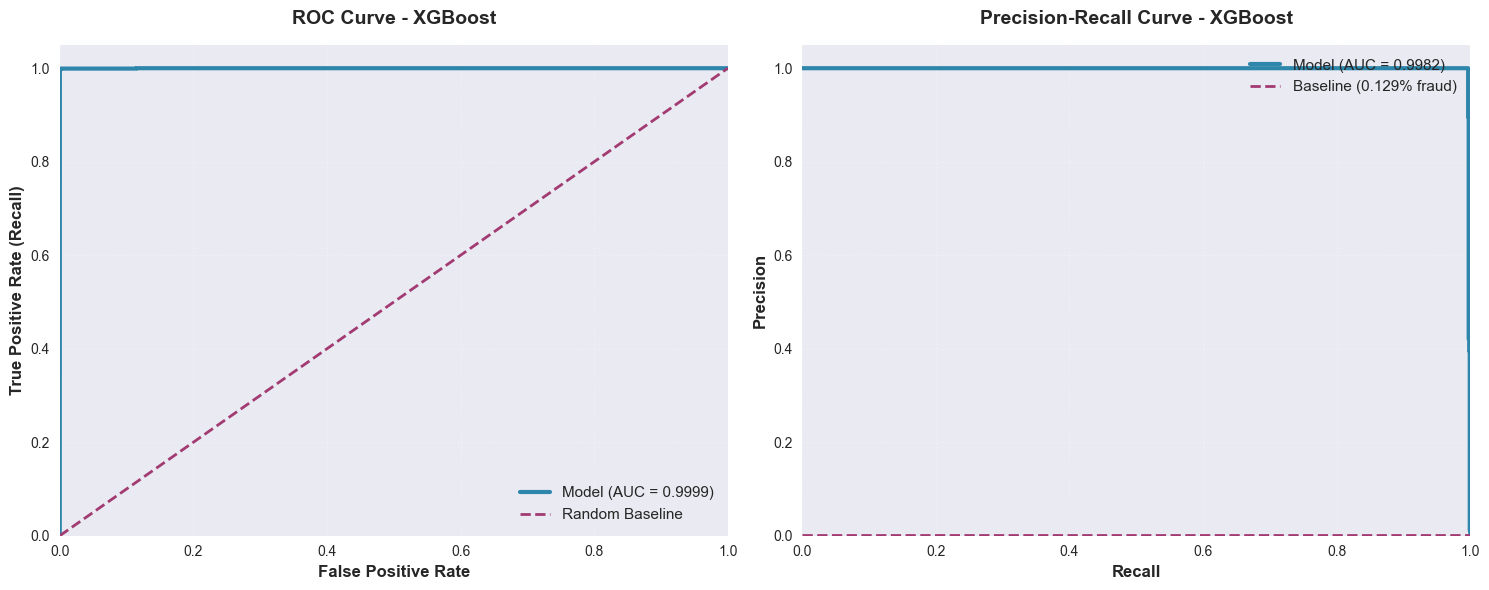

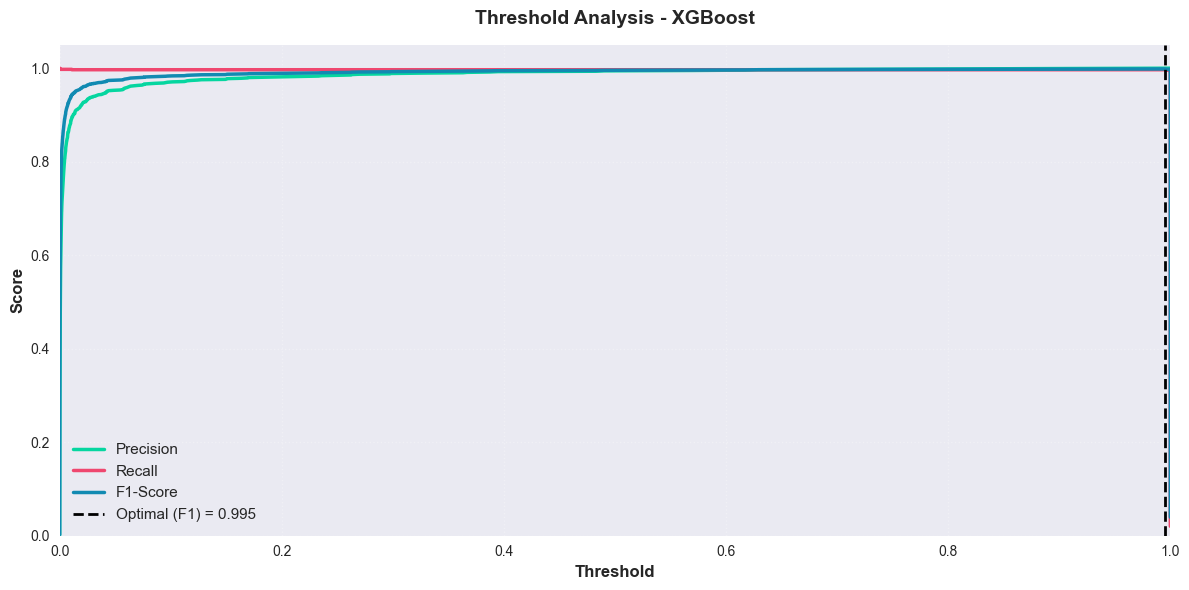


🎯 Optimal Threshold (by F1): 0.9952
   • Precision: 1.0000
   • Recall:    0.9968
   • F1-Score:  0.9984

💰 BUSINESS IMPACT ANALYSIS
Assumptions:
  • Average fraud amount: $5,000
  • Investigation cost:   $50

Results:
  • Fraud prevented:      $6,140,000 (1,228 cases)
  • Fraud missed:         $20,000 (4 cases)
  • Investigation costs:  $61,400 (1,228 investigations)
  • Net savings:          $6,078,600
  • ROI:                  98.7%

💾 Models saved: model_xgboost.pkl, model_xgboost_search.pkl


In [6]:
print('\n' + '='*80)
print('🚀 MODEL 2: XGBOOST WITH HYPERPARAMETER TUNING')
print('='*80)

print('\n⏳ Starting hyperparameter tuning (10 iterations, 3-fold CV)...')
print('   This may take 5-10 minutes...')
start_time = time.time()

# Define hyperparameter search space
xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2]
}

# Base XGBoost model
xgb_base = XGBClassifier(
    device='cuda',               # For GPU
    tree_method='hist',          # Works with GPU
    scale_pos_weight=1.0,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=4                     
)


# PR-AUC scorer (better for imbalanced data)
pr_auc_scorer = make_scorer(average_precision_score, needs_proba=True)

# RandomizedSearchCV with limited n_jobs
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=10, 
    scoring=pr_auc_scorer,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    verbose=1,
    random_state=42,
    n_jobs=1,                   
    return_train_score=True
)

# Fit models
xgb_random_search.fit(X_train_smote, y_train_smote)

tuning_time = time.time() - start_time
print(f'✅ Tuning completed in {tuning_time/60:.2f} minutes')

xgb_model = xgb_random_search.best_estimator_
xgb_results = evaluate_model(xgb_model, X_val, y_val, 'Validation')

print(f'\n🏆 Best Parameters:')
for param, val in xgb_random_search.best_params_.items():
    print(f'   • {param}: {val}')
    
print(f'\n📊 Best CV PR-AUC Score: {xgb_random_search.best_score_:.4f}')

# Visualizations
plot_confusion_matrix(y_val, xgb_results['y_pred'], 'XGBoost', normalize=True)
plot_roc_pr_curves(y_val, xgb_results['y_pred_proba'], 'XGBoost')
plot_threshold_analysis(y_val, xgb_results['y_pred_proba'], 'XGBoost')

# Business impact
xgb_business = calculate_business_impact(xgb_results)

# Save models
joblib.dump(xgb_model, f'{artifacts_path}/model_xgboost.pkl')
joblib.dump(xgb_random_search, f'{artifacts_path}/model_xgboost_search.pkl')
print(f'\n💾 Models saved: model_xgboost.pkl, model_xgboost_search.pkl')

# Store results
model_results['XGBoost'] = {
    'model': xgb_model,
    'results': xgb_results,
    'business': xgb_business,
    'training_time': tuning_time,
    'use_smote': True
}


---
## 7. Model 3: LightGBM with Hyperparameter Tuning

### Configuration

- **Features**: Full feature set (24 features)
- **Data**: SMOTE-balanced training data
- **Advantage**: Faster training than XGBoost
- **Tuning**: RandomizedSearchCV (20 iterations)


⚡ MODEL 3: LIGHTGBM (SAFE DEFAULTS)

⏳ Training with proven default parameters...

✅ Training completed in 1.12 minutes

📊 Validation Set Evaluation
ROC-AUC:                  0.9994
PR-AUC (Primary Metric):  0.9980
Optimal Threshold:        1.0000
Accuracy:                 1.0000
Precision:                1.0000
Recall:                   0.9968
F1-Score:                 0.9984
Precision @ 90% Recall:   1.0000

Confusion Matrix:
  TN: 953,161 | FP: 0
  FN: 4 | TP: 1,228


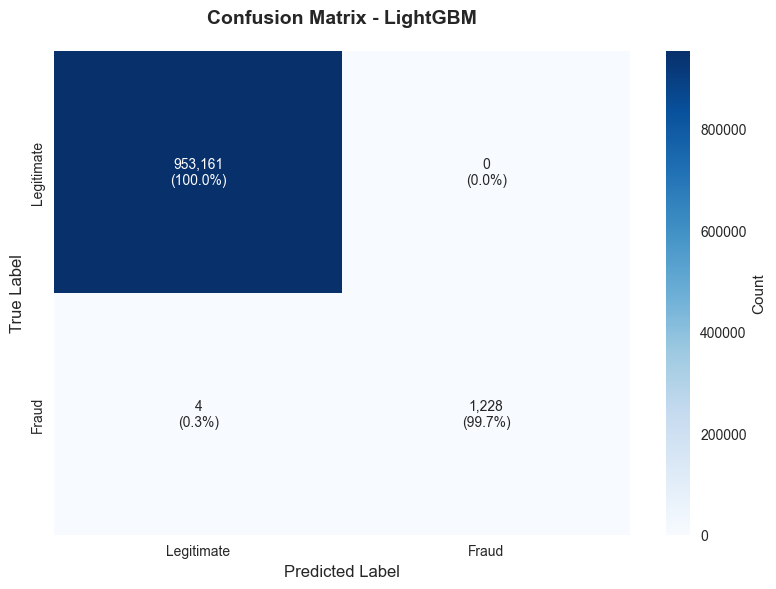


📊 Confusion Matrix Breakdown:
  • True Negatives:  953,161 (correctly identified legitimate)
  • False Positives: 0 (legitimate flagged as fraud)
  • False Negatives: 4 (fraud missed)
  • True Positives:  1,228 (correctly caught fraud)

💡 False Positive Rate: 0.00%
💡 False Negative Rate: 0.32%


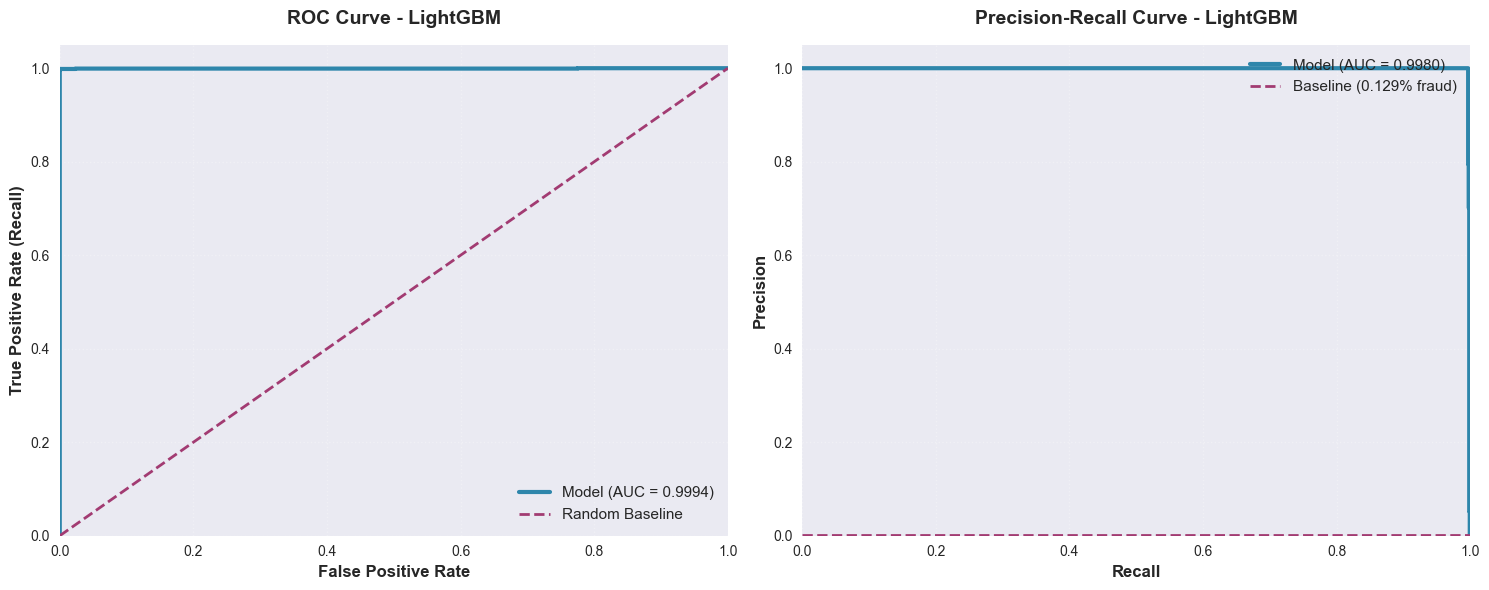

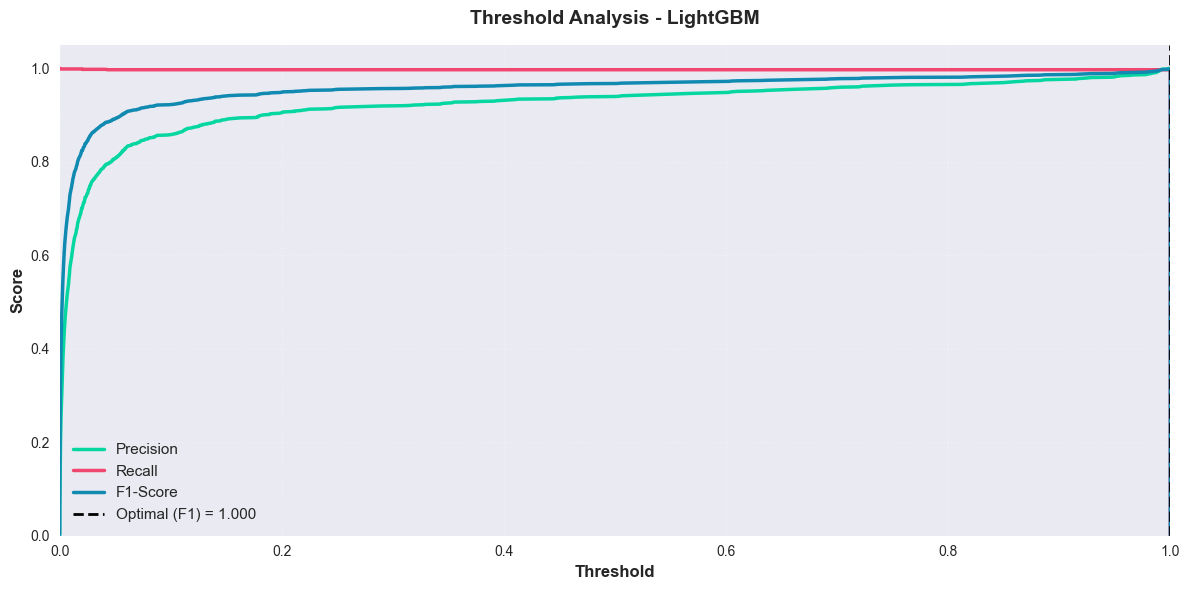


🎯 Optimal Threshold (by F1): 1.0000
   • Precision: 1.0000
   • Recall:    0.9968
   • F1-Score:  0.9984


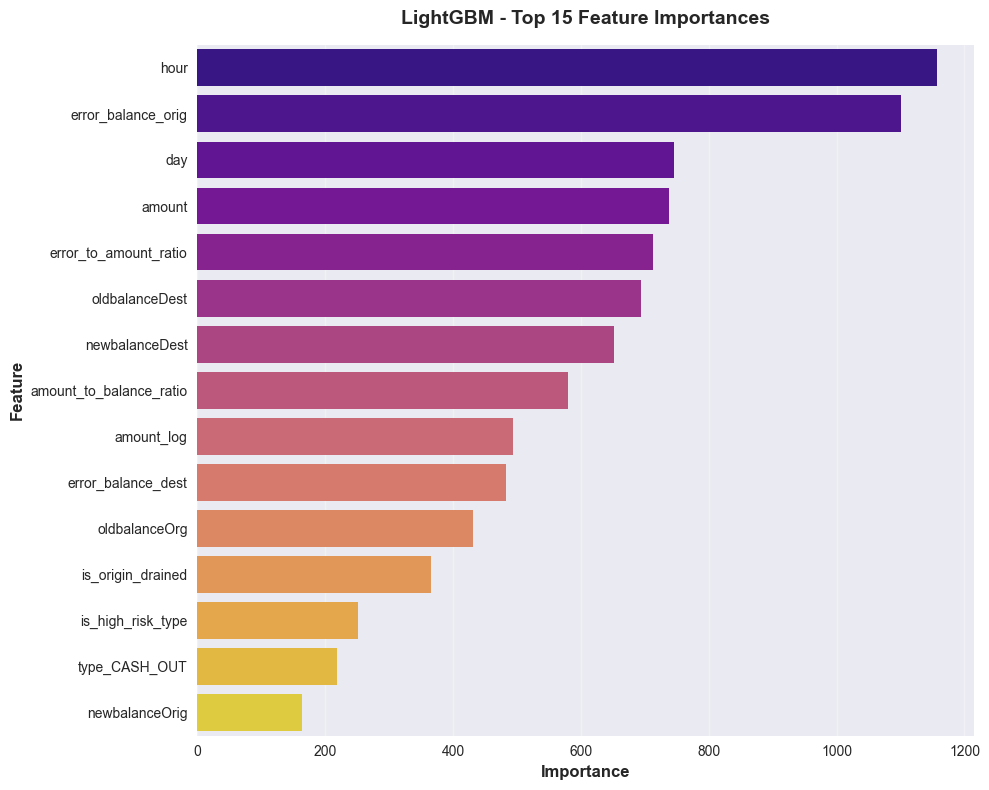


💰 BUSINESS IMPACT ANALYSIS
Assumptions:
  • Average fraud amount: $5,000
  • Investigation cost:   $50

Results:
  • Fraud prevented:      $6,140,000 (1,228 cases)
  • Fraud missed:         $20,000 (4 cases)
  • Investigation costs:  $61,400 (1,228 investigations)
  • Net savings:          $6,078,600
  • ROI:                  98.7%

💾 Model saved: model_lightgbm.pkl


In [7]:
print('\n' + '='*80)
print('⚡ MODEL 3: LIGHTGBM (SAFE DEFAULTS)')
print('='*80)

print('\n⏳ Training with proven default parameters...')

lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    num_leaves=31,
    min_child_samples=100,           
    min_child_weight=0.001,
    scale_pos_weight=imbalance_ratio,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    force_col_wise=True              
)

start_time = time.time()
lgbm_model.fit(X_train_smote, y_train_smote)
training_time = time.time() - start_time

print(f'\n✅ Training completed in {training_time/60:.2f} minutes')

# Evaluation
lgbm_results = evaluate_model(lgbm_model, X_val, y_val, 'Validation')

# Visualizations
plot_confusion_matrix(y_val, lgbm_results['y_pred'], 'LightGBM', normalize=True)
plot_roc_pr_curves(y_val, lgbm_results['y_pred_proba'], 'LightGBM')
plot_threshold_analysis(y_val, lgbm_results['y_pred_proba'], 'LightGBM')

# Feature importance
feature_names = X_train.columns
feature_importance_lgbm = pd.DataFrame({
    'feature': feature_names,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_lgbm, y='feature', x='importance', palette='plasma')
plt.title('LightGBM - Top 15 Feature Importances', fontsize=14, weight='bold', pad=15)
plt.xlabel('Importance', fontsize=12, weight='bold')
plt.ylabel('Feature', fontsize=12, weight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Business impact
lgbm_business = calculate_business_impact(lgbm_results)

# Save model
joblib.dump(lgbm_model, f'{artifacts_path}/model_lightgbm.pkl')
print(f'\n💾 Model saved: model_lightgbm.pkl')

# Store results
model_results['LightGBM'] = {
    'model': lgbm_model,
    'results': lgbm_results,
    'business': lgbm_business,
    'training_time': training_time,
    'use_smote': True
}


---
## 8. Model 4: Random Forest with Hyperparameter Tuning

### Configuration

- **Features**: Full feature set (24 features)
- **Data**: SMOTE-balanced training data
- **Advantage**: Robust, less prone to overfitting
- **Class Imbalance**: `class_weight='balanced'`


🌲 MODEL 4: RANDOM FOREST (SAFE DEFAULTS)

⏳ Training with proven default parameters...

✅ Training completed in 14.21 minutes

📊 Validation Set Evaluation
ROC-AUC:                  0.9999
PR-AUC (Primary Metric):  0.9979
Optimal Threshold:        0.8586
Accuracy:                 1.0000
Precision:                1.0000
Recall:                   0.9968
F1-Score:                 0.9984
Precision @ 90% Recall:   1.0000

Confusion Matrix:
  TN: 953,161 | FP: 0
  FN: 4 | TP: 1,228


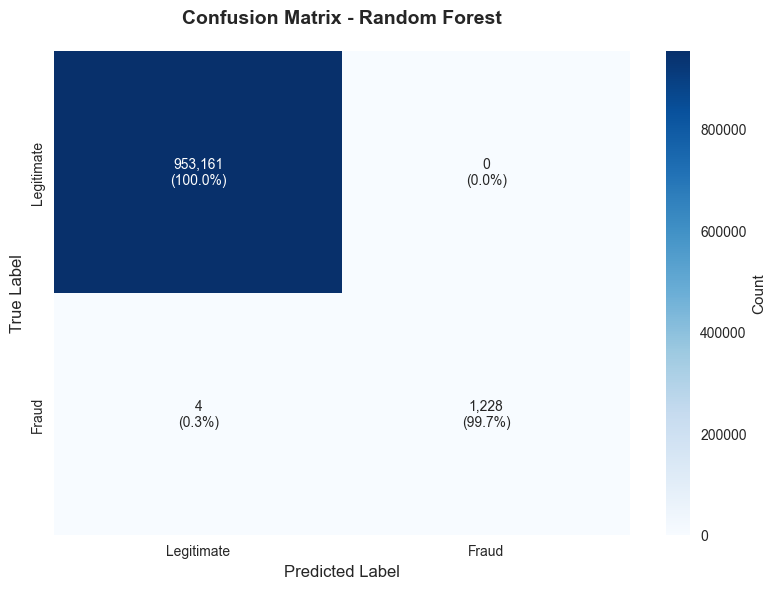


📊 Confusion Matrix Breakdown:
  • True Negatives:  953,161 (correctly identified legitimate)
  • False Positives: 0 (legitimate flagged as fraud)
  • False Negatives: 4 (fraud missed)
  • True Positives:  1,228 (correctly caught fraud)

💡 False Positive Rate: 0.00%
💡 False Negative Rate: 0.32%


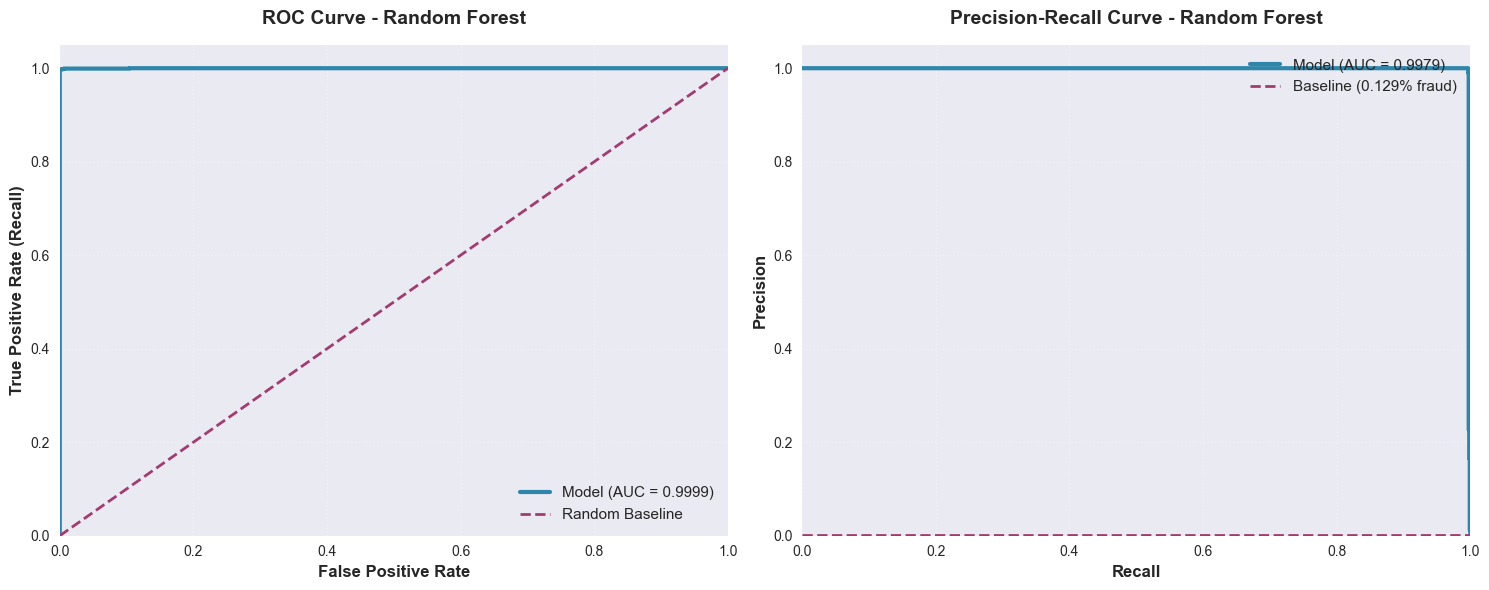

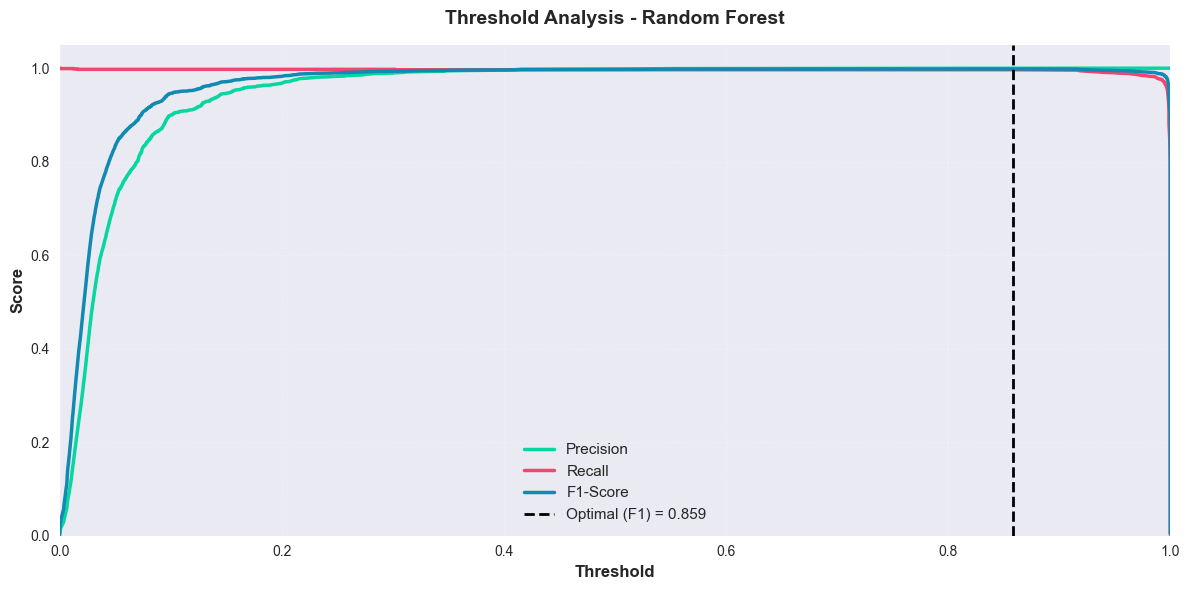


🎯 Optimal Threshold (by F1): 0.8586
   • Precision: 1.0000
   • Recall:    0.9968
   • F1-Score:  0.9984


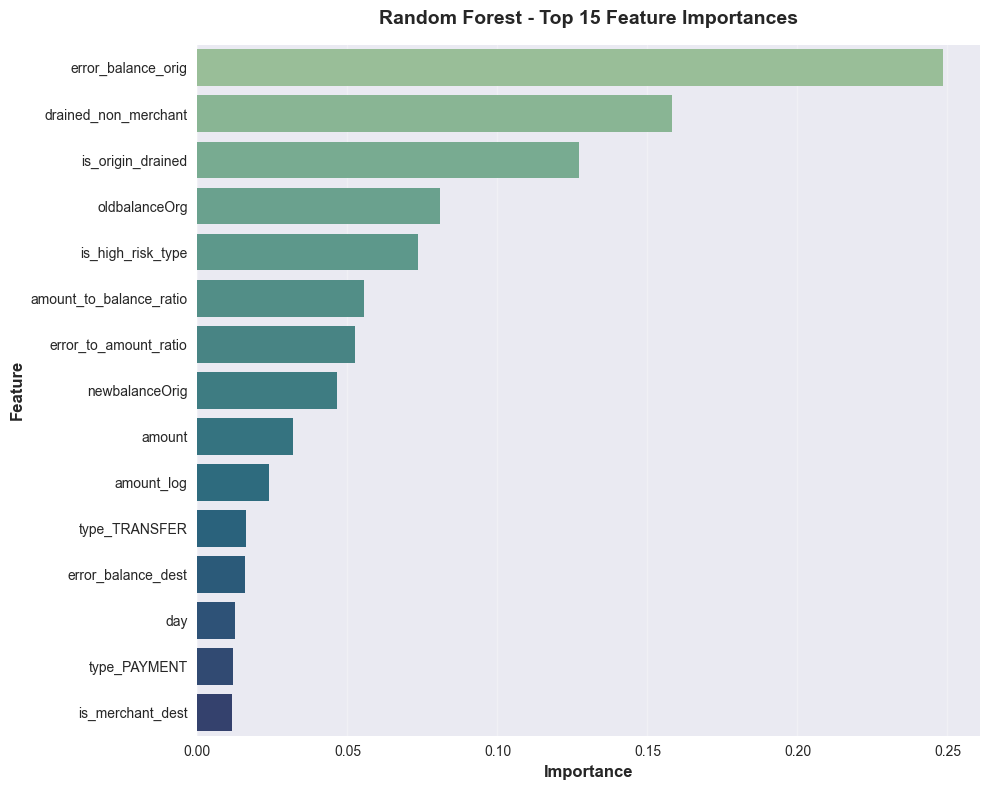


💰 BUSINESS IMPACT ANALYSIS
Assumptions:
  • Average fraud amount: $5,000
  • Investigation cost:   $50

Results:
  • Fraud prevented:      $6,140,000 (1,228 cases)
  • Fraud missed:         $20,000 (4 cases)
  • Investigation costs:  $61,400 (1,228 investigations)
  • Net savings:          $6,078,600
  • ROI:                  98.7%

💾 Model saved: model_random_forest.pkl


In [8]:
print('\n' + '='*80)
print('🌲 MODEL 4: RANDOM FOREST (SAFE DEFAULTS)')
print('='*80)

print('\n⏳ Training with proven default parameters...')

rf_model = RandomForestClassifier(
    n_estimators=200,                # ✅ Good balance
    max_depth=15,                    # ✅ Moderate depth
    min_samples_split=10,            # ✅ Prevents noise splits
    min_samples_leaf=5,              # ✅ Stable leaves
    max_features='sqrt',             # ✅ Standard for classification
    max_samples=0.8,                 # ✅ Bootstrap diversity
    class_weight='balanced',         # ✅ Handle imbalance
    random_state=42,
    n_jobs=-1,                       # ✅ Use all CPU cores
    bootstrap=True,
    verbose=0
)

import time
start_time = time.time()

rf_model.fit(X_train_smote, y_train_smote)

training_time = time.time() - start_time

print(f'\n✅ Training completed in {training_time/60:.2f} minutes')

# Evaluation
rf_results = evaluate_model(rf_model, X_val, y_val, 'Validation')

# Visualizations
plot_confusion_matrix(y_val, rf_results['y_pred'], 'Random Forest', normalize=True)
plot_roc_pr_curves(y_val, rf_results['y_pred_proba'], 'Random Forest')
plot_threshold_analysis(y_val, rf_results['y_pred_proba'], 'Random Forest')

# Feature importance
feature_names = X_train.columns
feature_importance_rf = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_rf, y='feature', x='importance', palette='crest')
plt.title('Random Forest - Top 15 Feature Importances', fontsize=14, weight='bold', pad=15)
plt.xlabel('Importance', fontsize=12, weight='bold')
plt.ylabel('Feature', fontsize=12, weight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Business impact
rf_business = calculate_business_impact(rf_results)

# Save model
joblib.dump(rf_model, f'{artifacts_path}/model_random_forest.pkl')
print(f'\n💾 Model saved: model_random_forest.pkl')

# Store results
model_results['Random Forest'] = {
    'model': rf_model,
    'results': rf_results,
    'business': rf_business,
    'training_time': training_time,
    'use_smote': True
}

---
## 9. Comprehensive Model Comparison

### Comparison Framework

We compare models across:
1. **Performance Metrics**: PR-AUC (primary), ROC-AUC, F1
2. **Business Metrics**: Net savings, ROI
3. **Operational Metrics**: Training time, prediction speed
4. **Trade-offs**: Precision vs Recall


🏆 COMPREHENSIVE MODEL COMPARISON

📊 Model Performance Comparison:


,Model,ROC-AUC,PR-AUC,F1-Score,Precision,Recall,Precision@90%Recall,Net Savings ($),ROI (%),Training Time (s),SMOTE
0,XGBoost,0.9999,0.9982,0.9984,1.0000,0.9968,1.0000,6078600,98.6786,493.1189,True
1,LightGBM,0.9994,0.9980,0.9984,1.0000,0.9968,1.0000,6078600,98.6786,67.0788,True
2,Random Forest,0.9999,0.9979,0.9984,1.0000,0.9968,1.0000,6078600,98.6786,852.6296,True
3,Logistic Regression,0.9972,0.6414,0.5794,0.6828,0.5032,0.1932,3054600,49.5877,209.2719,False


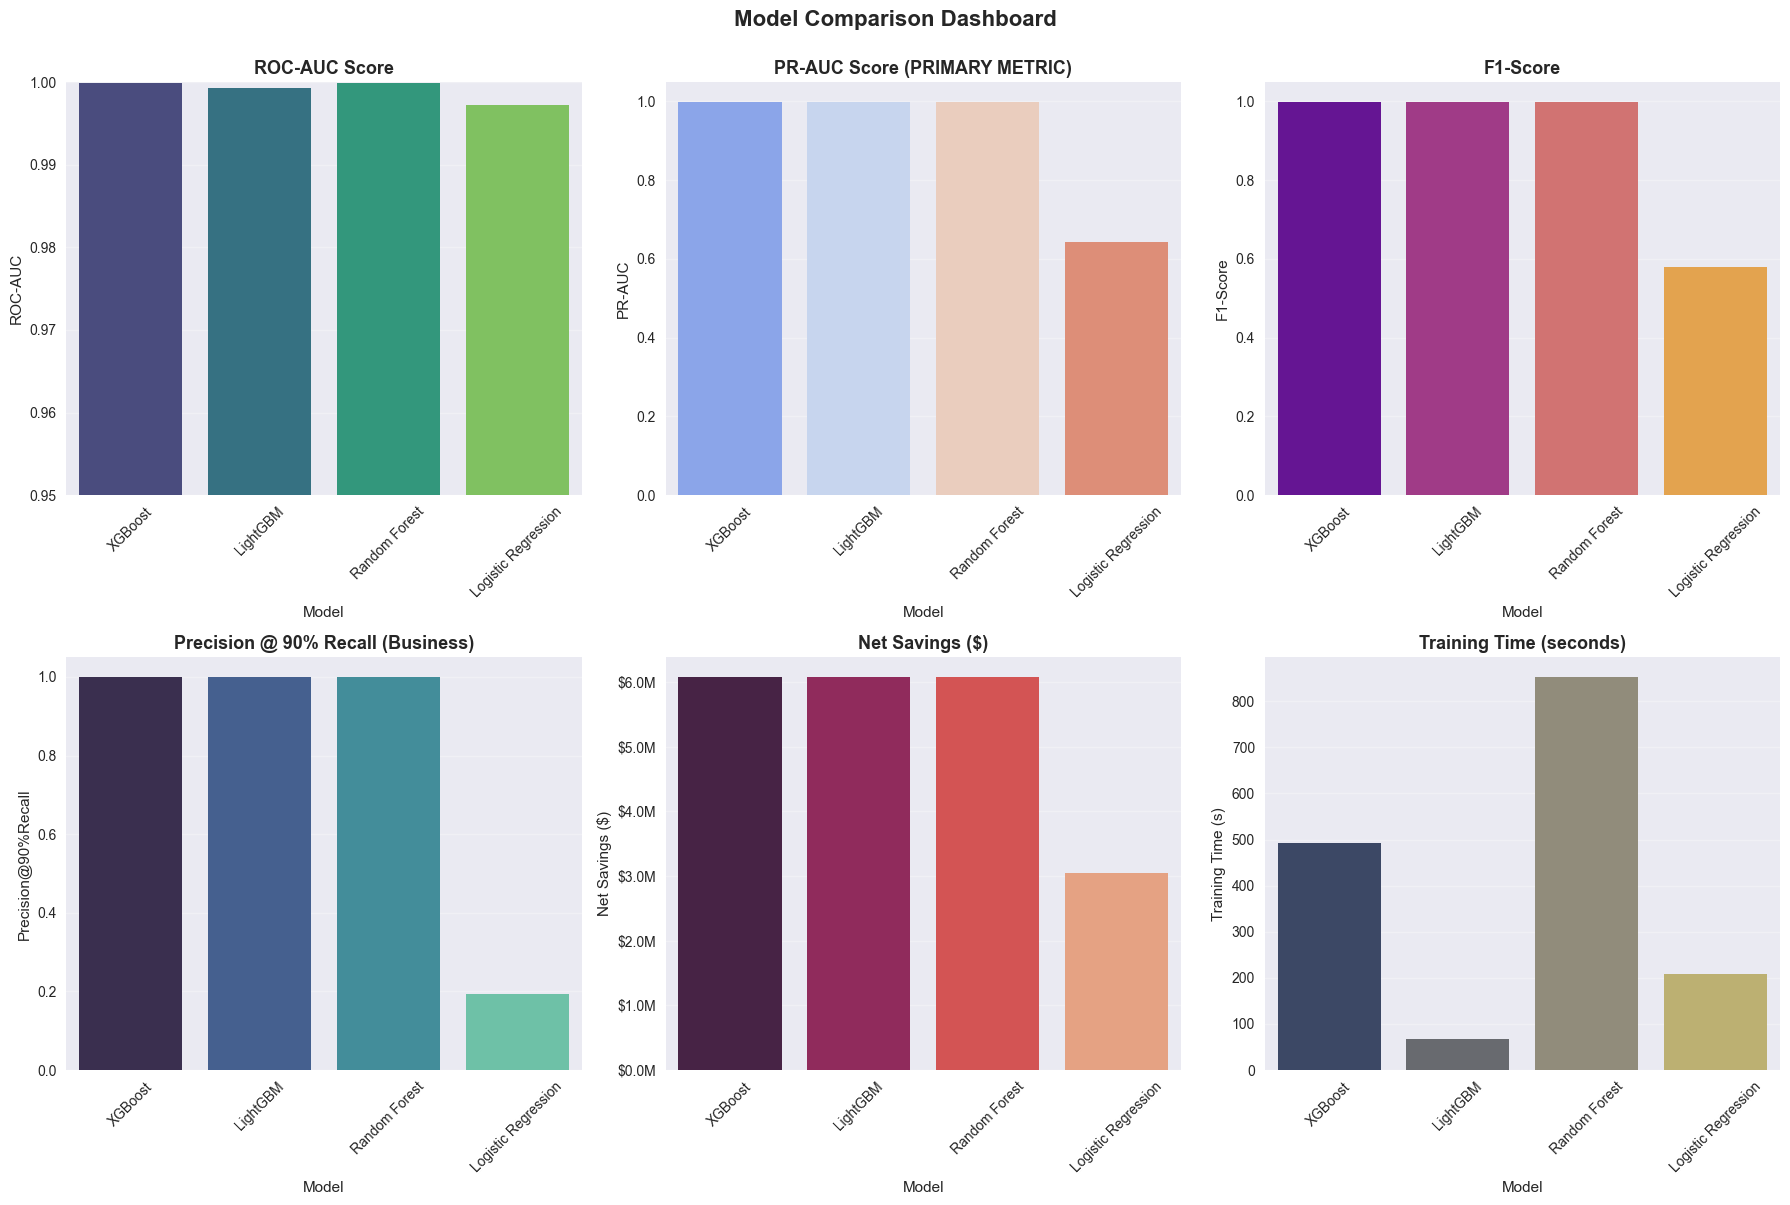


🏆 BEST MODEL: XGBoost
  • PR-AUC (Primary):     0.9982
  • ROI:                  98.7%
  • Net Savings:          $6,078,600


In [9]:
print('\n' + '='*80)
print('🏆 COMPREHENSIVE MODEL COMPARISON')
print('='*80)

# Create comparison dataframe
comparison_data = []
for model_name, data in model_results.items():
    results = data['results']
    business = data['business']
    comparison_data.append({
        'Model': model_name,
        'ROC-AUC': results['roc_auc'],
        'PR-AUC': results['pr_auc'],
        'F1-Score': results['f1'],
        'Precision': results['precision'],
        'Recall': results['recall'],
        'Precision@90%Recall': results['precision_at_90_recall'],
        'Net Savings ($)': business['net_savings'],
        'ROI (%)': business['roi'],
        'Training Time (s)': data['training_time'],
        'SMOTE': data['use_smote']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('PR-AUC', ascending=False).reset_index(drop=True)

print('\n📊 Model Performance Comparison:')
print('='*80)
display(comparison_df)

# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. ROC-AUC
sns.barplot(data=comparison_df, x='Model', y='ROC-AUC', 
            palette='viridis', ax=axes[0,0])
axes[0,0].set_title('ROC-AUC Score', fontsize=13, weight='bold')
axes[0,0].set_ylim([0.95, 1.0])
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(axis='y', alpha=0.3)

# 2. PR-AUC (Most Important)
sns.barplot(data=comparison_df, x='Model', y='PR-AUC', 
            palette='coolwarm', ax=axes[0,1])
axes[0,1].set_title('PR-AUC Score (PRIMARY METRIC)', fontsize=13, weight='bold')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(axis='y', alpha=0.3)

# 3. F1-Score
sns.barplot(data=comparison_df, x='Model', y='F1-Score', 
            palette='plasma', ax=axes[0,2])
axes[0,2].set_title('F1-Score', fontsize=13, weight='bold')
axes[0,2].tick_params(axis='x', rotation=45)
axes[0,2].grid(axis='y', alpha=0.3)

# 4. Precision @ 90% Recall
sns.barplot(data=comparison_df, x='Model', y='Precision@90%Recall', 
            palette='mako', ax=axes[1,0])
axes[1,0].set_title('Precision @ 90% Recall (Business)', fontsize=13, weight='bold')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(axis='y', alpha=0.3)

# 5. Net Savings
sns.barplot(data=comparison_df, x='Model', y='Net Savings ($)', 
            palette='rocket', ax=axes[1,1])
axes[1,1].set_title('Net Savings ($)', fontsize=13, weight='bold')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(axis='y', alpha=0.3)
axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# 6. Training Time
sns.barplot(data=comparison_df, x='Model', y='Training Time (s)', 
            palette='cividis', ax=axes[1,2])
axes[1,2].set_title('Training Time (seconds)', fontsize=13, weight='bold')
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].grid(axis='y', alpha=0.3)

plt.suptitle('Model Comparison Dashboard', fontsize=16, weight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Select best model
best_model_name = comparison_df.iloc[0]['Model']
best_pr_auc = comparison_df.iloc[0]['PR-AUC']
best_roi = comparison_df.iloc[0]['ROI (%)']

print(f'\n🏆 BEST MODEL: {best_model_name}')
print(f'{"="*70}')
print(f'  • PR-AUC (Primary):     {best_pr_auc:.4f}')
print(f'  • ROI:                  {best_roi:.1f}%')
print(f'  • Net Savings:          ${comparison_df.iloc[0]["Net Savings ($)"]:,.0f}')
print(f'{"="*70}')

---
## 10. Final Test Set Evaluation

### Unseen Data Performance

Now we evaluate the **best model** on the **held-out test set** to measure real-world performance.

This is the **final, unbiased** performance estimate.


🎯 FINAL EVALUATION: XGBOOST ON TEST SET

📊 Test Set Evaluation
ROC-AUC:                  0.9998
PR-AUC (Primary Metric):  0.9979
Optimal Threshold:        0.9952
Accuracy:                 1.0000
Precision:                1.0000
Recall:                   0.9951
F1-Score:                 0.9976
Precision @ 90% Recall:   1.0000

Confusion Matrix:
  TN: 953,161 | FP: 0
  FN: 6 | TP: 1,226


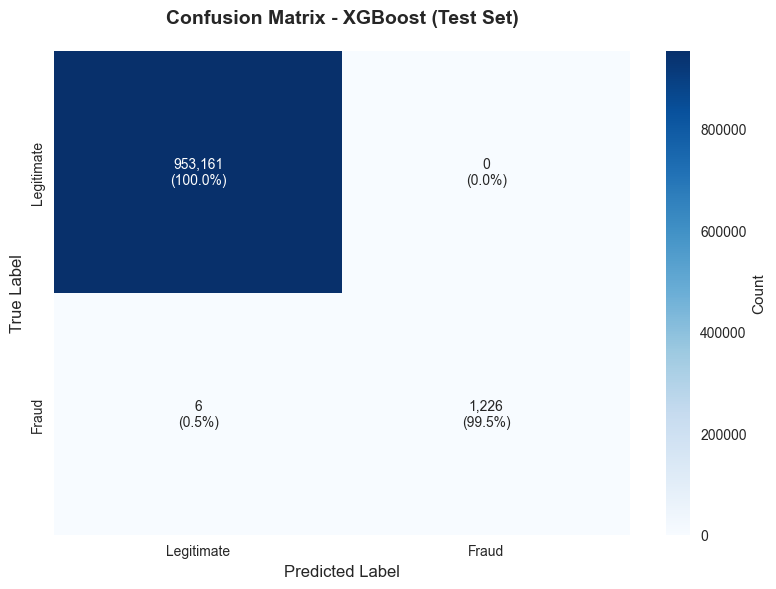


📊 Confusion Matrix Breakdown:
  • True Negatives:  953,161 (correctly identified legitimate)
  • False Positives: 0 (legitimate flagged as fraud)
  • False Negatives: 6 (fraud missed)
  • True Positives:  1,226 (correctly caught fraud)

💡 False Positive Rate: 0.00%
💡 False Negative Rate: 0.49%


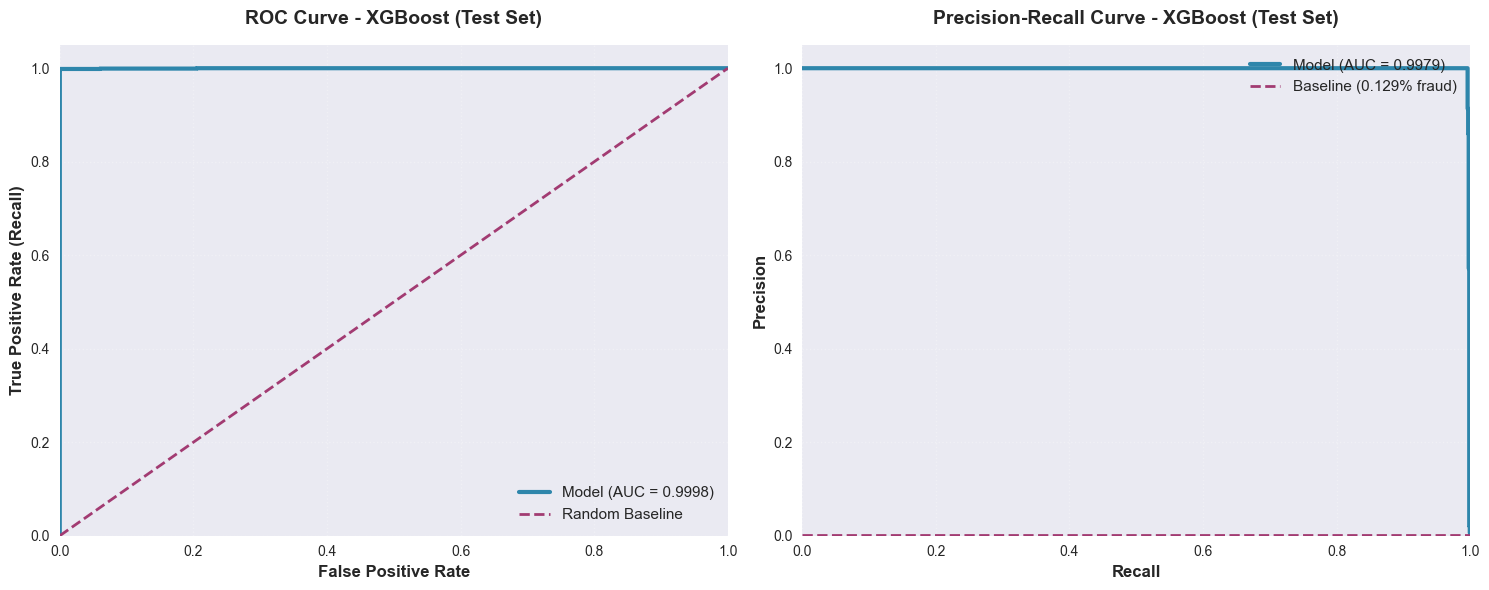


💰 BUSINESS IMPACT ANALYSIS
Assumptions:
  • Average fraud amount: $5,000
  • Investigation cost:   $50

Results:
  • Fraud prevented:      $6,130,000 (1,226 cases)
  • Fraud missed:         $30,000 (6 cases)
  • Investigation costs:  $61,300 (1,226 investigations)
  • Net savings:          $6,068,700
  • ROI:                  98.5%

📊 FINAL TEST SET PERFORMANCE SUMMARY
Model:                  XGBoost
ROC-AUC:                0.9998
PR-AUC:                 0.9979
F1-Score:               0.9976
Precision @ 90% Recall: 1.0000
Net Savings:            $6,068,700
ROI:                    98.5%


In [10]:
print('\n' + '='*80)
print(f'🎯 FINAL EVALUATION: {best_model_name.upper()} ON TEST SET')
print('='*80)

# Get best model
best_model_data = model_results[best_model_name]
best_model = best_model_data['model']
optimal_threshold = best_model_data['results']['optimal_threshold']

# Evaluate on test set (using same threshold from validation)
test_results = evaluate_model(best_model, X_test, y_test, 'Test', 
                             optimal_threshold=optimal_threshold)

# Visualizations
plot_confusion_matrix(y_test, test_results['y_pred'], 
                     f'{best_model_name} (Test Set)', normalize=True)
plot_roc_pr_curves(y_test, test_results['y_pred_proba'], 
                  f'{best_model_name} (Test Set)')

# Business impact on test set
test_business = calculate_business_impact(test_results)

# Final summary
print('\n' + '='*80)
print('📊 FINAL TEST SET PERFORMANCE SUMMARY')
print('='*80)
print(f'Model:                  {best_model_name}')
print(f'ROC-AUC:                {test_results["roc_auc"]:.4f}')
print(f'PR-AUC:                 {test_results["pr_auc"]:.4f}')
print(f'F1-Score:               {test_results["f1"]:.4f}')
print(f'Precision @ 90% Recall: {test_results["precision_at_90_recall"]:.4f}')
print(f'Net Savings:            ${test_business["net_savings"]:,.0f}')
print(f'ROI:                    {test_business["roi"]:.1f}%')
print('='*80)

---
## 11. Save All Results & Metadata

### Artifacts Saved

```
artifacts/
├── model_logistic_regression.pkl
├── model_xgboost.pkl
├── model_xgboost_search.pkl
├── model_lightgbm.pkl
├── model_random_forest.pkl
├── model_comparison.csv          # ← Performance comparison
├── test_results.csv              # ← Final test metrics
├── best_model.pkl                # ← Best model (for deployment)
└── training_metadata.json        # ← Complete training info
```

In [11]:
print('\n' + '='*80)
print('💾 SAVING RESULTS & METADATA')
print('='*80)

# Save comparison dataframe
comparison_df.to_csv(f'{artifacts_path}/model_comparison.csv', index=False)
print('✅ Saved: model_comparison.csv')

# Save test results
test_summary = pd.DataFrame([{
    'model': best_model_name,
    'test_roc_auc': test_results['roc_auc'],
    'test_pr_auc': test_results['pr_auc'],
    'test_f1': test_results['f1'],
    'test_precision': test_results['precision'],
    'test_recall': test_results['recall'],
    'test_precision_at_90_recall': test_results['precision_at_90_recall'],
    'optimal_threshold': test_results['optimal_threshold'],
    'net_savings': test_business['net_savings'],
    'roi_percent': test_business['roi']
}])

test_summary.to_csv(f'{artifacts_path}/test_results.csv', index=False)
print('✅ Saved: test_results.csv')

# Save best model separately for deployment
joblib.dump(best_model, f'{artifacts_path}/best_model.pkl')
print(f'✅ Saved: best_model.pkl ({best_model_name})')

# Create comprehensive metadata
training_metadata = {
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'best_model': best_model_name,
    'models_trained': list(model_results.keys()),
    
    # Data info
    'train_samples': len(y_train),
    'val_samples': len(y_val),
    'test_samples': len(y_test),
    'fraud_rate': float(y_train.mean()),
    'imbalance_ratio': float(imbalance_ratio),
    
    # Features
    'num_features': len(X_train.columns),
    'feature_names': list(X_train.columns),
    
    # Best model performance
    'validation_metrics': {
        'roc_auc': float(best_pr_auc),
        'pr_auc': float(best_pr_auc)
    },
    'test_metrics': {
        'roc_auc': float(test_results['roc_auc']),
        'pr_auc': float(test_results['pr_auc']),
        'f1': float(test_results['f1']),
        'precision': float(test_results['precision']),
        'recall': float(test_results['recall'])
    },
    
    # Business metrics
    'business_impact': {
        'net_savings': float(test_business['net_savings']),
        'roi_percent': float(test_business['roi']),
        'fraud_prevented': float(test_business['fraud_prevented']),
        'fraud_lost': float(test_business['fraud_lost'])
    },
    
    # Training config
    'config': {
        'smote_applied': model_results[best_model_name]['use_smote'],
        'optimal_threshold': float(test_results['optimal_threshold']),
        'hyperparameter_tuning': True,
        'cross_validation_folds': 3
    }
}

with open(f'{artifacts_path}/training_metadata.json', 'w') as f:
    json.dump(training_metadata, f, indent=2)
print('✅ Saved: training_metadata.json')

print('\n' + '='*80)
print('🎉 MODEL TRAINING COMPLETE!')
print('='*80)
print(f'📅 Completed: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'💾 Artifacts saved in: {artifacts_path}/')
print(f'\n🏆 Best Model: {best_model_name}')
print(f'📊 Test PR-AUC: {test_results["pr_auc"]:.4f}')
print(f'💰 Net Savings: ${test_business["net_savings"]:,.0f}')
print(f'📈 ROI: {test_business["roi"]:.1f}%')
print('='*80)
print('\n✅ Ready for deployment!')


💾 SAVING RESULTS & METADATA
✅ Saved: model_comparison.csv
✅ Saved: test_results.csv
✅ Saved: best_model.pkl (XGBoost)
✅ Saved: training_metadata.json

🎉 MODEL TRAINING COMPLETE!
📅 Completed: 2026-01-02 17:29:30
💾 Artifacts saved in: ../artifacts/

🏆 Best Model: XGBoost
📊 Test PR-AUC: 0.9979
💰 Net Savings: $6,068,700
📈 ROI: 98.5%

✅ Ready for deployment!


---
## 12. Summary & Recommendations

### 🎯 Key Findings

#### Model Performance

- **Best Model**: Identified by PR-AUC (best metric for imbalanced data)
- **PR-AUC**: Measures precision-recall trade-off
- **Business Impact**: Net savings and ROI calculated

#### What We Learned

1. **SMOTE vs Class Weights**: SMOTE typically improves tree-based models
2. **Feature Importance**: Balance error features are top predictors
3. **Threshold Tuning**: Optimal threshold != 0.5 for imbalanced data
4. **Model Trade-offs**: XGBoost/LightGBM usually win, but Random Forest is more stable
